# Sampling NLA Amplitudes for Machine-Learning Compression

NLA.ipynb defined the individual alignment factors and POWER.ipynb recombined them
into the signed IA amplitude. This notebook builds nuisance-only amplitude datasets
for developing and testing machine-learning compression.

## The path through the notebook

The notebook has two stages:

- a completed example using a reproducible starting prior;
- a student workspace for comparing and refining nuisance-parameter prior ranges.

By the end, you should be able to:

- translate prior ranges into a reproducible parameter matrix;
- generate factorized model tensors with explicit and verified shapes;
- identify extreme curves before using a prior for ML training;
- compare candidate priors using the same random samples;
- save parameters, physical components, diagnostics, and metadata together.

The ranges used here are phenomenological training priors, not observational priors.
The aim is to find ranges that are varied enough for compression while remaining
numerically controlled on the chosen redshift and wavenumber grid.

---

## Set up an independent sampling notebook

This notebook imports the canonical model class from Alignment.py and can run from a
fresh kernel. Cosmological parameters and matter power spectra are deliberately kept
outside this sampling exercise, so the dataset isolates nuisance-model variation.

In [1]:
import json
import sys
from pathlib import Path

import h5py
import numpy
from matplotlib import pyplot

In [2]:
pyplot.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 20,
    "text.usetex": True,
})

colour_list = ["red", "orange", "black", "blue", "purple"]

In [3]:
base_path = Path.cwd().parent if Path.cwd().name == "Code" else Path.cwd()
code_path = base_path / "Code"
data_path = base_path / "Data" / "SAMPLE"
figure_path = base_path / "Figure" / "SAMPLE"

data_path.mkdir(parents=True, exist_ok=True)
figure_path.mkdir(parents=True, exist_ok=True)

if str(code_path) not in sys.path:
    sys.path.insert(0, str(code_path))

from Alignment import Z_STAR, NLAModel, pivot_redshift_ratio

print("Project directory:", base_path)
print("Code directory:   ", code_path)
print("Data directory:   ", data_path)
print("Figure directory: ", figure_path)

Project directory: /Users/s2227120/Downloads/IAFlowCloud
Code directory:    /Users/s2227120/Downloads/IAFlowCloud/Code
Data directory:    /Users/s2227120/Downloads/IAFlowCloud/Data/SAMPLE
Figure directory:  /Users/s2227120/Downloads/IAFlowCloud/Figure/SAMPLE


---

## Define the compression target

The complete nuisance-model target is

$$
\mathcal A_\Theta(k,z\mid\boldsymbol\Theta)
=A_0\,R_z(z)\,R_L(z)\,S(k,z),
\qquad R_z(z)=r_\ast^\eta(z),
$$

with

$$
\boldsymbol\Theta=
(A_0,\eta,\xi,s,z_q,q,n^\ast,k_t^\ast,\alpha,m,\gamma_t,\gamma_n).
$$

For a simple teaching prior, the parameters are sampled independently:

$$
\pi(\boldsymbol\Theta)=\prod_j\pi_j(\theta_j).
$$

This independence is a modelling choice for dataset construction, not a claim about
parameter correlations in observations. We retain $R_z$, $R_L$, and $S(k,z)$ as well
as $\mathcal A_\Theta$, so later compression tests can inspect the physical factors
rather than only the final product. The factors $R_z$, $R_L$, and $S$ are strictly
positive, while the signed normalization $A_0$ sets the sign of
$\mathcal A_\Theta$. The special case $A_0=0$ gives zero model amplitude.

### Define a reproducible starting prior

| Parameter | Starting range | Sampling rule |
|---|---:|---|
| $A_0$ | $[-4,+4]$ | uniform |
| $\eta$ | $[-2,+2]$ | uniform |
| $\xi$ | $[-2,+2]$ | uniform |
| $s$ | $[1,10]$ | uniform |
| $z_q$ | $[0.5,2.5]$ | uniform |
| $q$ | $[0,2.5]$ | uniform |
| $n^\ast$ | $[1,5]$ | uniform |
| $k_t^\ast$ | $[0.1,1.0]\,{\rm Mpc}^{-1}$ | log-uniform |
| $\alpha$ | $[-0.5,+0.5]$ | uniform |
| $m$ | $[1,5]$ | uniform; deliberately conservative |
| $\gamma_t$ | $[-1.0,+1.0]$ | uniform |
| $\gamma_n$ | $[-0.5,+0.5]$ | uniform |

These ranges are a starting hypothesis. The diagnostics below determine whether they
produce useful diversity without unacceptable boundary behaviour.

In [4]:
def validate_prior_specification(prior_specification):
    """Validate the sampled parameters, bounds, rules, and canonical order."""
    expected_names = tuple(NLAModel.SAMPLED_PARAMETER_NAMES)
    if tuple(prior_specification) != expected_names:
        raise ValueError(
            "The prior parameters must follow NLAModel.SAMPLED_PARAMETER_NAMES."
        )

    for parameter_name, specification in prior_specification.items():
        minimum = float(specification["minimum"])
        maximum = float(specification["maximum"])
        distribution = specification["distribution"]

        if not numpy.isfinite(minimum) or not numpy.isfinite(maximum):
            raise ValueError(f"{parameter_name} prior limits must be finite.")
        if minimum >= maximum:
            raise ValueError(f"{parameter_name} requires minimum < maximum.")
        if distribution not in {"uniform", "log_uniform"}:
            raise ValueError(f"Unsupported distribution for {parameter_name}.")
        if distribution == "log_uniform" and minimum <= 0.0:
            raise ValueError(f"{parameter_name} requires positive log-uniform bounds.")


def transform_unit_samples(unit_samples, prior_specification):
    """Transform unit-cube samples into the requested nuisance prior."""
    validate_prior_specification(prior_specification)
    unit_samples = numpy.asarray(unit_samples, dtype=float)
    expected_columns = len(prior_specification)

    if unit_samples.ndim != 2 or unit_samples.shape[1] != expected_columns:
        raise ValueError("unit_samples must have shape (number_of_models, 12).")
    if not numpy.all(numpy.isfinite(unit_samples)):
        raise ValueError("unit_samples must contain finite values.")
    if numpy.any((unit_samples < 0.0) | (unit_samples > 1.0)):
        raise ValueError("unit_samples must lie between zero and one.")

    parameter_samples = numpy.empty_like(unit_samples)

    for parameter_index, specification in enumerate(prior_specification.values()):
        minimum = float(specification["minimum"])
        maximum = float(specification["maximum"])

        if specification["distribution"] == "uniform":
            parameter_samples[:, parameter_index] = (
                minimum + unit_samples[:, parameter_index] * (maximum - minimum)
            )
        else:
            log_minimum = numpy.log10(minimum)
            log_maximum = numpy.log10(maximum)
            parameter_samples[:, parameter_index] = 10.0**(
                log_minimum
                + unit_samples[:, parameter_index] * (log_maximum - log_minimum)
            )

    return parameter_samples

In [5]:
starting_prior = {
    "A0": {"minimum": -4.0, "maximum": 4.0, "distribution": "uniform"},
    "eta": {"minimum": -2.0, "maximum": 2.0, "distribution": "uniform"},
    "xi": {"minimum": -2.0, "maximum": 2.0, "distribution": "uniform"},
    "s": {"minimum": 1.0, "maximum": 10.0, "distribution": "uniform"},
    "z_q": {"minimum": 0.5, "maximum": 2.5, "distribution": "uniform"},
    "q": {"minimum": 0.0, "maximum": 2.5, "distribution": "uniform"},
    "n_star": {"minimum": 1.0, "maximum": 5.0, "distribution": "uniform"},
    "k_t_star": {"minimum": 0.1, "maximum": 1.0, "distribution": "log_uniform"},
    "alpha": {"minimum": -0.5, "maximum": 0.5, "distribution": "uniform"},
    "m": {"minimum": 1.0, "maximum": 5.0, "distribution": "uniform"},
    "gamma_t": {"minimum": -1.0, "maximum": 1.0, "distribution": "uniform"},
    "gamma_n": {"minimum": -0.5, "maximum": 0.5, "distribution": "uniform"},
}

random_seed = 2026
number_of_models = 1000
nuisance_parameter_names = list(NLAModel.SAMPLED_PARAMETER_NAMES)

rng = numpy.random.default_rng(random_seed)
unit_samples = rng.random((number_of_models, len(nuisance_parameter_names)))
nuisance_parameters = transform_unit_samples(unit_samples, starting_prior)

z1 = 0.0
z2 = 3.0
z_size = 6
z_training = numpy.linspace(z1, z2, z_size + 1)

logk1 = -3.0
logk2 = +1.0
logk_size = 100
k_training = numpy.logspace(logk1, logk2, logk_size + 1)
r_star_training = pivot_redshift_ratio(z_training, z_star=Z_STAR)

print("nuisance parameters:", nuisance_parameters.shape)
print("redshift grid:      ", z_training)
print("wavenumber grid:    ", k_training.shape)
print("r_star grid:        ", r_star_training)

nuisance parameters: (1000, 12)
redshift grid:       [0.  0.5 1.  1.5 2.  2.5 3. ]
wavenumber grid:     (101,)
r_star grid:         [0.66666667 1.         1.33333333 1.66666667 2.         2.33333333
 2.66666667]


---

## Generate the factorized nuisance dataset

Each parameter row generates two redshift factors and two $(N_z,N_k)$ surfaces:

$$
\boldsymbol\Theta_i
\longrightarrow
\left\{R_z^{(i)}(z),R_L^{(i)}(z),S^{(i)}(k,z),
\mathcal A_\Theta^{(i)}(k,z)\right\}.
$$

A temporary validity mask records whether each candidate model can be evaluated with
finite components, positive $R_z$, $R_L$, and $S$, and an amplitude whose sign follows
$A_0$. It is used to assess a prior, but it is not saved in an accepted final dataset
because every stored model must pass these checks.

In [6]:
def build_boundary_parameter_samples(prior_specification):
    """Build a midpoint model and one-at-a-time lower and upper boundary models."""
    validate_prior_specification(prior_specification)
    midpoint = []

    for specification in prior_specification.values():
        minimum = float(specification["minimum"])
        maximum = float(specification["maximum"])
        if specification["distribution"] == "log_uniform":
            midpoint.append(numpy.sqrt(minimum * maximum))
        else:
            midpoint.append(0.5 * (minimum + maximum))

    boundary_samples = [numpy.asarray(midpoint)]
    for parameter_index, specification in enumerate(prior_specification.values()):
        lower_sample = numpy.asarray(midpoint).copy()
        upper_sample = numpy.asarray(midpoint).copy()
        lower_sample[parameter_index] = specification["minimum"]
        upper_sample[parameter_index] = specification["maximum"]
        boundary_samples.extend([lower_sample, upper_sample])

    return numpy.asarray(boundary_samples)


def generate_component_samples(parameter_samples, z, k):
    """Generate R_z, R_L, S_k_z, and A_theta for every parameter row."""
    parameter_samples = numpy.asarray(parameter_samples, dtype=float)
    number_of_samples = len(parameter_samples)
    redshift_shape = (number_of_samples, len(z))
    surface_shape = (number_of_samples, len(z), len(k))

    components = {
        "R_z": numpy.full(redshift_shape, numpy.nan),
        "R_L": numpy.full(redshift_shape, numpy.nan),
        "S_k_z": numpy.full(surface_shape, numpy.nan),
        "A_theta": numpy.full(surface_shape, numpy.nan),
    }
    valid_mask = numpy.zeros(number_of_samples, dtype=bool)
    failure_messages = {}
    A0_index = list(NLAModel.SAMPLED_PARAMETER_NAMES).index("A0")

    for model_index, values in enumerate(parameter_samples):
        try:
            with numpy.errstate(over="raise", invalid="raise", divide="raise"):
                model = NLAModel.from_array(values, z_star=Z_STAR)
                model_components = {
                    "R_z": model.redshift_factor(z),
                    "R_L": model.luminosity_factor(z),
                    "S_k_z": model.scale_dependence(z, k),
                    "A_theta": model.model_amplitude(z, k),
                }

            for component_name, component_values in model_components.items():
                if not numpy.all(numpy.isfinite(component_values)):
                    raise ValueError(f"{component_name} contains non-finite values.")

            for component_name in ["R_z", "R_L", "S_k_z"]:
                if not numpy.all(model_components[component_name] > 0.0):
                    raise ValueError(f"{component_name} must remain positive.")

            expected_A_theta = (
                values[A0_index]
                * model_components["R_z"][:, None]
                * model_components["R_L"][:, None]
                * model_components["S_k_z"]
            )
            if not numpy.allclose(model_components["A_theta"], expected_A_theta):
                raise ValueError("A_theta must equal A0 * R_z * R_L * S_k_z.")
            if not numpy.all(
                numpy.sign(model_components["A_theta"])
                == numpy.sign(values[A0_index])
            ):
                raise ValueError("A_theta must have the same sign as A0.")
            
            for component_name in components:
                components[component_name][model_index] = model_components[component_name]
            valid_mask[model_index] = True

        except (FloatingPointError, TypeError, ValueError) as error:
            failure_messages[model_index] = str(error)

    return components, valid_mask, failure_messages

In [7]:
component_samples, valid_mask, failure_messages = generate_component_samples(
    nuisance_parameters,
    z_training,
    k_training,
)

R_z_samples = component_samples["R_z"]
R_L_samples = component_samples["R_L"]
S_k_z_samples = component_samples["S_k_z"]
A_theta_samples = component_samples["A_theta"]

boundary_parameters = build_boundary_parameter_samples(starting_prior)
boundary_components, boundary_valid_mask, boundary_failures = generate_component_samples(
    boundary_parameters,
    z_training,
    k_training,
)

print("R_z samples:      ", R_z_samples.shape)
print("R_L samples:      ", R_L_samples.shape)
print("S_k_z samples:    ", S_k_z_samples.shape)
print("A_theta samples:  ", A_theta_samples.shape)
print("random validity:  ", valid_mask.mean())
print("boundary validity:", boundary_valid_mask.mean())

R_z samples:       (1000, 7)
R_L samples:       (1000, 7)
S_k_z samples:     (1000, 7, 101)
A_theta samples:   (1000, 7, 101)
random validity:   1.0
boundary validity: 1.0


### Validate the generated tensors

Before plotting or saving, verify the parameter bounds, component shapes, finiteness,
positivity of $R_z$, $R_L$, and $S$, the signed-amplitude identity, canonical class
order, model round trip, pivot identity
$r_\ast(z_\ast)=1$, and the deterministic boundary stress set.

In [8]:
expected_redshift_shape = (number_of_models, len(z_training))
expected_surface_shape = (number_of_models, len(z_training), len(k_training))

assert nuisance_parameter_names == list(NLAModel.SAMPLED_PARAMETER_NAMES)
assert nuisance_parameters.shape == (
    number_of_models,
    len(nuisance_parameter_names),
)
assert R_z_samples.shape == expected_redshift_shape
assert R_L_samples.shape == expected_redshift_shape
assert S_k_z_samples.shape == expected_surface_shape
assert A_theta_samples.shape == expected_surface_shape
assert numpy.all(valid_mask), failure_messages
assert numpy.all(boundary_valid_mask), boundary_failures

for parameter_index, specification in enumerate(starting_prior.values()):
    assert numpy.all(nuisance_parameters[:, parameter_index] >= specification["minimum"])
    assert numpy.all(nuisance_parameters[:, parameter_index] <= specification["maximum"])

for component_values in component_samples.values():
    assert numpy.all(numpy.isfinite(component_values))

for component_name in ["R_z", "R_L", "S_k_z"]:
    assert numpy.all(component_samples[component_name] > 0.0)

A0_index = nuisance_parameter_names.index("A0")
A0_samples = nuisance_parameters[:, A0_index]
expected_A_theta = (
    A0_samples[:, None, None]
    * R_z_samples[:, :, None]
    * R_L_samples[:, :, None]
    * S_k_z_samples
)
assert numpy.allclose(A_theta_samples, expected_A_theta)
assert numpy.all(
    numpy.sign(A_theta_samples) == numpy.sign(A0_samples)[:, None, None]
)

pivot_matches = numpy.flatnonzero(numpy.isclose(z_training, Z_STAR))
assert len(pivot_matches) == 1
pivot_index = pivot_matches[0]
high_redshift_index = -1
assert numpy.isclose(r_star_training[pivot_index], 1.0)

for model_index in [0, number_of_models - 1]:
    reconstructed_values = NLAModel.from_array(
        nuisance_parameters[model_index],
        z_star=Z_STAR,
    ).to_array()
    assert numpy.allclose(reconstructed_values, nuisance_parameters[model_index])

print("All nuisance-only dataset checks passed.")

All nuisance-only dataset checks passed.


---

## Quantify prior breadth and extreme models

Define the positive model factor

$$
F_\Theta(k,z)=R_z(z)R_L(z)S(k,z)>0,
\qquad \mathcal A_\Theta=A_0F_\Theta.
$$

For model $i$, the normalization-independent logarithmic dynamic range is

$$
D_i=\max_{z,k}\log_{10}F_{\Theta,i}
-\min_{z,k}\log_{10}F_{\Theta,i}.
$$

This remains defined when $A_0=0$. To measure ensemble shape diversity, define

$$
W_{\rm shape}(z,k)=Q_{99}[\log_{10}F_\Theta]
-Q_1[\log_{10}F_\Theta].
$$

The prior summary records the median and maximum of $W_{\rm shape}$ across the grid.
An extreme flag identifies the upper one per cent of $D_i$ for inspection; it does not
mean that those models are invalid.

In [9]:
def combine_positive_model_factors(component_samples):
    """Combine R_z, R_L, and S_k_z without the signed normalization A0."""
    return (
        component_samples["R_z"][:, :, None]
        * component_samples["R_L"][:, :, None]
        * component_samples["S_k_z"]
    )


def calculate_prior_diagnostics(component_samples, sample_valid_mask):
    """Calculate signed-amplitude and positive-factor diagnostics."""
    A_theta = component_samples["A_theta"]
    model_factor = combine_positive_model_factors(component_samples)
    number_of_samples = len(A_theta)
    minimum_A_theta = numpy.full(number_of_samples, numpy.nan)
    maximum_A_theta = numpy.full(number_of_samples, numpy.nan)
    log_dynamic_range = numpy.full(number_of_samples, numpy.nan)
    extreme_flag = numpy.zeros(number_of_samples, dtype=bool)

    valid_indices = numpy.flatnonzero(sample_valid_mask)
    if len(valid_indices) == 0:
        raise ValueError("At least one valid model is required for diagnostics.")

    valid_amplitudes = A_theta[valid_indices]
    valid_model_factors = model_factor[valid_indices]
    minimum_A_theta[valid_indices] = valid_amplitudes.min(axis=(1, 2))
    maximum_A_theta[valid_indices] = valid_amplitudes.max(axis=(1, 2))
    log_dynamic_range[valid_indices] = (
        numpy.log10(valid_model_factors.max(axis=(1, 2)))
        - numpy.log10(valid_model_factors.min(axis=(1, 2)))
    )

    extreme_threshold = numpy.quantile(log_dynamic_range[valid_indices], 0.99)
    extreme_flag[valid_indices] = (
        log_dynamic_range[valid_indices] >= extreme_threshold
    )

    return {
        "minimum_A_theta": minimum_A_theta,
        "maximum_A_theta": maximum_A_theta,
        "log_dynamic_range": log_dynamic_range,
        "extreme_flag": extreme_flag,
    }


def summarize_prior(
    candidate_name,
    component_samples,
    sample_valid_mask,
    boundary_mask,
    diagnostics,
):
    """Return a compact comparison summary for one candidate prior."""
    valid_ranges = diagnostics["log_dynamic_range"][sample_valid_mask]
    model_factors = combine_positive_model_factors(component_samples)
    valid_model_factors = model_factors[sample_valid_mask]
    shape_quantiles = numpy.quantile(
        numpy.log10(valid_model_factors),
        [0.01, 0.99],
        axis=0,
    )
    pointwise_shape_spread = shape_quantiles[1] - shape_quantiles[0]
    return {
        "candidate": candidate_name,
        "valid_fraction": float(sample_valid_mask.mean()),
        "boundary_valid_fraction": float(boundary_mask.mean()),
        "median_log_dynamic_range": float(numpy.median(valid_ranges)),
        "maximum_log_dynamic_range": float(numpy.max(valid_ranges)),
        "median_pointwise_shape_spread": float(numpy.median(pointwise_shape_spread)),
        "maximum_pointwise_shape_spread": float(numpy.max(pointwise_shape_spread)),
    }


prior_diagnostics = calculate_prior_diagnostics(
    component_samples,
    valid_mask,
)
starting_summary = summarize_prior(
    "starting_prior",
    component_samples,
    valid_mask,
    boundary_valid_mask,
    prior_diagnostics,
)

extreme_indices = numpy.argsort(prior_diagnostics["log_dynamic_range"])[-5:][::-1]

print(json.dumps(starting_summary, indent=2))
print("\nFive largest dynamic ranges and their parameter combinations:")
model_factor_samples = combine_positive_model_factors(component_samples)

for model_index in extreme_indices:
    minimum_location = numpy.unravel_index(
        numpy.argmin(model_factor_samples[model_index]),
        model_factor_samples[model_index].shape,
    )
    maximum_location = numpy.unravel_index(
        numpy.argmax(model_factor_samples[model_index]),
        model_factor_samples[model_index].shape,
    )
    parameter_text = ", ".join(
        f"{name}={value:.4g}"
        for name, value in zip(
            nuisance_parameter_names,
            nuisance_parameters[model_index],
        )
    )
    print(
        f"model {model_index}: D={prior_diagnostics['log_dynamic_range'][model_index]:.3f}, "
        f"minimum at (z={z_training[minimum_location[0]]:.1f}, "
        f"k={k_training[minimum_location[1]]:.3g}), "
        f"maximum at (z={z_training[maximum_location[0]]:.1f}, "
        f"k={k_training[maximum_location[1]]:.3g})"
    )
    print("   ", parameter_text)

{
  "candidate": "starting_prior",
  "valid_fraction": 1.0,
  "boundary_valid_fraction": 1.0,
  "median_log_dynamic_range": 1.0232343437453464,
  "maximum_log_dynamic_range": 2.4254637391073355,
  "median_pointwise_shape_spread": 1.2825659484681133,
  "maximum_pointwise_shape_spread": 2.6070339699538616
}

Five largest dynamic ranges and their parameter combinations:
model 61: D=2.425, minimum at (z=3.0, k=0.001), maximum at (z=0.0, k=10)
    A0=0.9974, eta=-1.994, xi=-1.403, s=4.751, z_q=1.075, q=1.686, n_star=4.963, k_t_star=0.1844, alpha=0.3107, m=2.485, gamma_t=0.4476, gamma_n=-0.4113
model 367: D=2.342, minimum at (z=3.0, k=0.001), maximum at (z=0.0, k=10)
    A0=3.644, eta=-1.775, xi=-1.77, s=4.243, z_q=1.183, q=1.323, n_star=3.446, k_t_star=0.665, alpha=0.4833, m=4.144, gamma_t=0.8373, gamma_n=0.4527
model 873: D=2.306, minimum at (z=3.0, k=0.001), maximum at (z=0.0, k=10)
    A0=-2.765, eta=-1.176, xi=-1.869, s=5.969, z_q=1.005, q=1.555, n_star=4.618, k_t_star=0.1759, alpha=0.4

---

## Inspect the ensemble with three focused figures

Every plot uses all 1000 models as thin rasterized curves. The median and central
quantile regions make the overall range readable without hiding rare cases. The scale
and amplitude figures compare $z=0$ and $z=3$ in paired panels, and the amplitude
figure highlights the five models with the largest full-grid dynamic range.

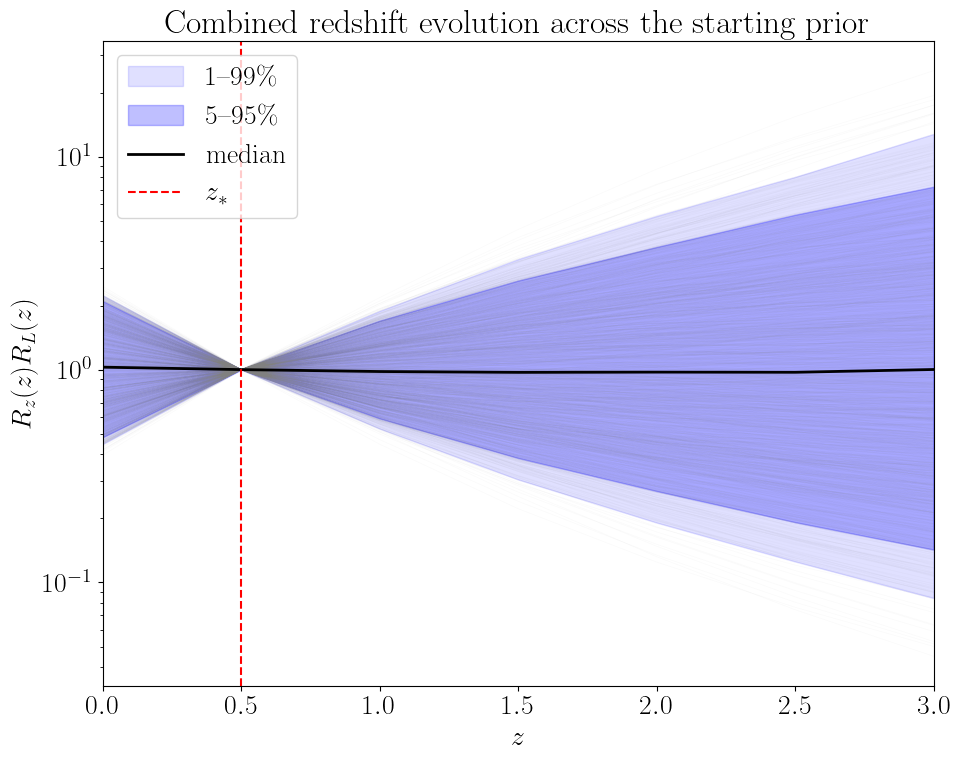

In [10]:
def add_ensemble_summary(plot, coordinate, curves, line_colour="grey"):
    """Plot all curves together with their median and central quantile regions."""
    quantiles = numpy.quantile(curves, [0.01, 0.05, 0.5, 0.95, 0.99], axis=0)

    plot.plot(
        coordinate,
        curves.T,
        color=line_colour,
        linewidth=0.5,
        alpha=0.04,
        rasterized=True,
    )
    plot.fill_between(
        coordinate,
        quantiles[0],
        quantiles[4],
        color="blue",
        alpha=0.12,
        label=r"$1$--$99\%$",
        rasterized=True,
    )
    plot.fill_between(
        coordinate,
        quantiles[1],
        quantiles[3],
        color="blue",
        alpha=0.25,
        label=r"$5$--$95\%$",
        rasterized=True,
    )
    plot.plot(
        coordinate,
        quantiles[2],
        color="black",
        linewidth=2.0,
        label="median",
        rasterized=True,
    )


def set_signed_amplitude_scale(plot, amplitudes, linear_threshold=None):
    """Use a symmetric logarithmic scale for positive and negative amplitudes."""
    if linear_threshold is None:
        absolute_amplitudes = numpy.abs(amplitudes)
        nonzero_amplitudes = absolute_amplitudes[absolute_amplitudes > 0.0]
        linear_threshold = (
            numpy.quantile(nonzero_amplitudes, 0.01)
            if len(nonzero_amplitudes) > 0
            else 1.0
        )
    plot.set_yscale("symlog", linthresh=linear_threshold)
    plot.axhline(0.0, color="grey", linestyle="--", rasterized=True)
    return linear_threshold


redshift_evolution_samples = R_z_samples * R_L_samples

figure, plot = pyplot.subplots(figsize=(10, 8))

add_ensemble_summary(plot, z_training, redshift_evolution_samples)

plot.axvline(Z_STAR, color="red", linestyle="--", label=r"$z_\ast$", rasterized=True)

plot.set_xlim(z1, z2)
plot.set_yscale("log")

plot.set_xlabel(r"$z$")
plot.set_ylabel(r"$R_z(z)R_L(z)$")
plot.set_title("Combined redshift evolution across the starting prior")

plot.legend()
figure.tight_layout()
figure.savefig(figure_path / "Redshift_Evolution_Ensemble.pdf", dpi=512, bbox_inches="tight")

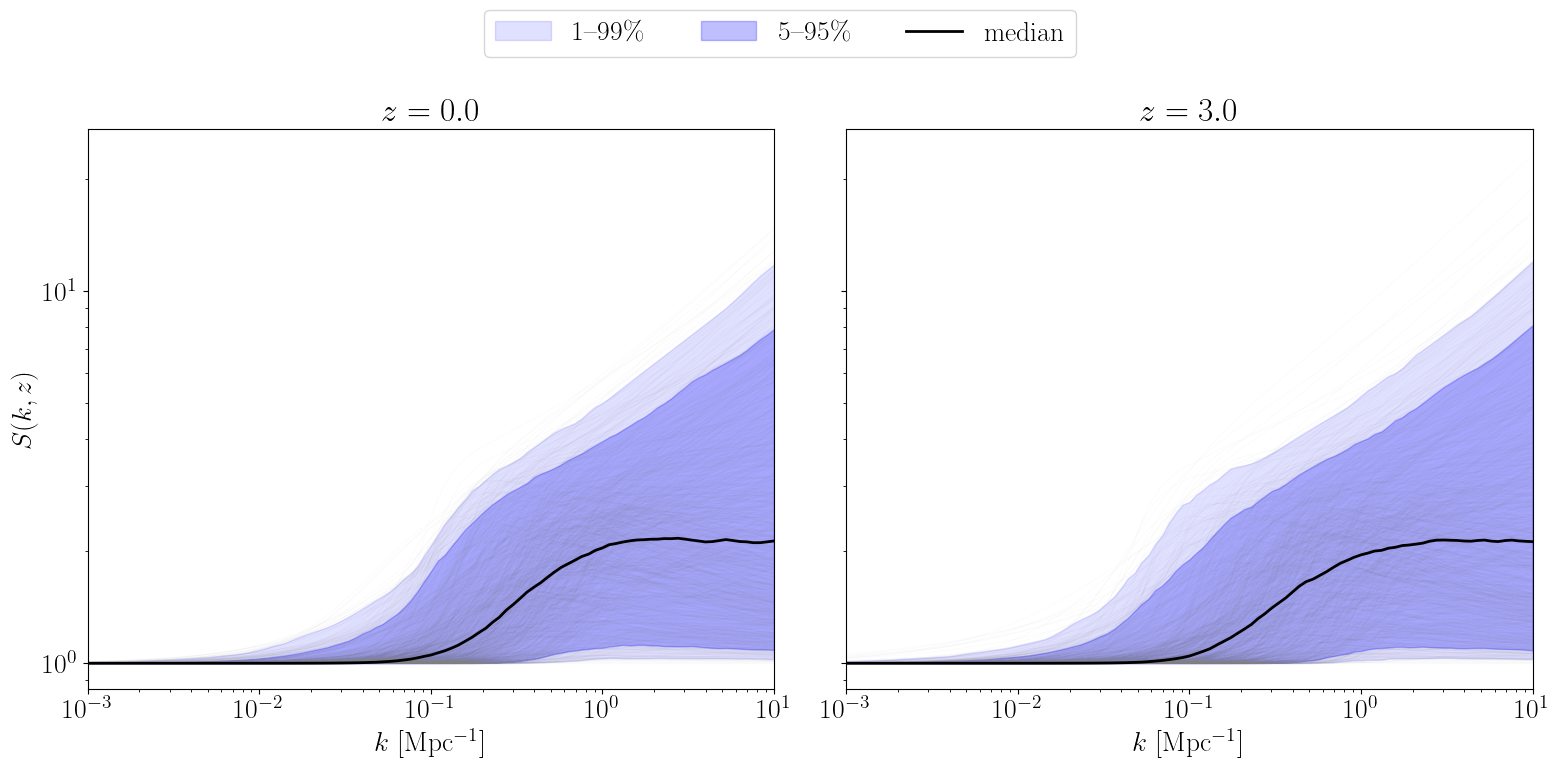

In [11]:
endpoint_indices = [0, -1]
figure, plots = pyplot.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 8),
    sharex=True,
    sharey=True,
)

for plot, redshift_index in zip(plots, endpoint_indices):
    add_ensemble_summary(
        plot,
        k_training,
        S_k_z_samples[:, redshift_index, :],
    )
    plot.set_xscale("log")
    plot.set_yscale("log")
    plot.set_xlim(10**logk1, 10**logk2)
    plot.set_xlabel(r"$k$ [Mpc$^{-1}$]")
    plot.set_title(rf"$z={z_training[redshift_index]:.1f}$")

plots[0].set_ylabel(r"$S(k,z)$")
legend_handles, legend_labels = plots[0].get_legend_handles_labels()
figure.legend(
    legend_handles,
    legend_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.99),
    ncols=3,
)
figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.90))
figure.savefig(figure_path / "Scale_Factor_Ensemble.pdf", dpi=512, bbox_inches="tight")

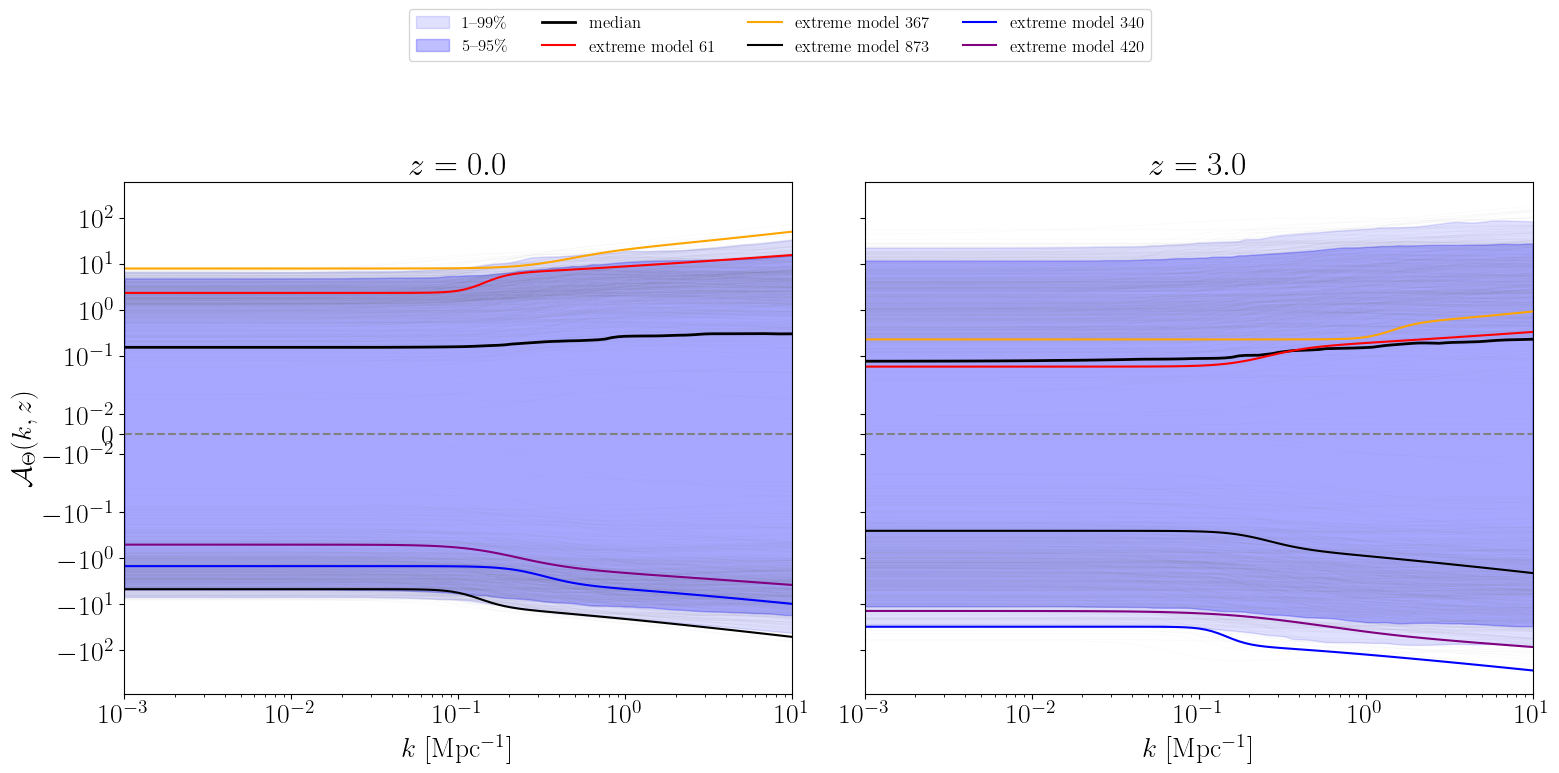

In [12]:
endpoint_indices = [0, -1]
endpoint_amplitudes = A_theta_samples[:, endpoint_indices, :]
nonzero_endpoint_amplitudes = numpy.abs(endpoint_amplitudes)[
    numpy.abs(endpoint_amplitudes) > 0.0
]
common_linear_threshold = (
    numpy.quantile(nonzero_endpoint_amplitudes, 0.01)
    if len(nonzero_endpoint_amplitudes) > 0
    else 1.0
)

figure, plots = pyplot.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 8),
    sharex=True,
    sharey=True,
)

for panel_index, (plot, redshift_index) in enumerate(zip(plots, endpoint_indices)):
    add_ensemble_summary(
        plot,
        k_training,
        A_theta_samples[:, redshift_index, :],
    )

    for colour, model_index in zip(colour_list, extreme_indices):
        label = f"extreme model {model_index}" if panel_index == 0 else "_nolegend_"
        plot.plot(
            k_training,
            A_theta_samples[model_index, redshift_index],
            color=colour,
            linewidth=1.5,
            label=label,
            rasterized=True,
        )

    plot.set_xscale("log")
    plot.set_xlim(10**logk1, 10**logk2)
    set_signed_amplitude_scale(
        plot,
        A_theta_samples[:, redshift_index, :],
        linear_threshold=common_linear_threshold,
    )
    plot.set_xlabel(r"$k$ [Mpc$^{-1}$]")
    plot.set_title(rf"$z={z_training[redshift_index]:.1f}$")

plots[0].set_ylabel(r"$\mathcal A_\Theta(k,z)$")
legend_handles, legend_labels = plots[0].get_legend_handles_labels()
figure.legend(
    legend_handles,
    legend_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.99),
    ncols=4,
    fontsize=12,
)
figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.84))
figure.savefig(figure_path / "Model_Amplitude_Ensemble.pdf", dpi=512, bbox_inches="tight")

---

## Save the factorized nuisance dataset

HDF5 keeps the aligned parameter rows, physical components, coordinates, diagnostics,
and prior metadata in one structured file. Raw physical arrays are saved before any
logarithm, standardization, PCA, or neural compression.

In [13]:
def save_nuisance_dataset(
    output_file,
    parameter_samples,
    component_samples,
    diagnostics,
    prior_specification,
    metadata,
):
    """Save one fully validated nuisance dataset in a structured HDF5 file."""
    output_file = Path(output_file)
    output_file.parent.mkdir(parents=True, exist_ok=True)
    compression_options = {
        "compression": "gzip",
        "compression_opts": 4,
        "shuffle": True,
    }

    with h5py.File(output_file, "w") as dataset:
        dataset.attrs["schema_version"] = "1.0"
        dataset.attrs["sample_scope"] = "nuisance parameters only"
        dataset.attrs["prior_specification"] = json.dumps(prior_specification)
        dataset.attrs["metadata"] = json.dumps(metadata)

        coordinates_group = dataset.create_group("coordinates")
        coordinates_group.create_dataset("z", data=z_training)
        coordinates_group.create_dataset("k", data=k_training)
        coordinates_group.create_dataset("r_star", data=r_star_training)

        parameters_group = dataset.create_group("parameters")
        parameters_group.create_dataset(
            "values",
            data=parameter_samples,
            **compression_options,
        )
        string_type = h5py.string_dtype(encoding="utf-8")
        parameters_group.create_dataset(
            "names",
            data=numpy.asarray(nuisance_parameter_names, dtype=object),
            dtype=string_type,
        )

        components_group = dataset.create_group("components")
        for component_name in ["R_z", "R_L", "S_k_z", "A_theta"]:
            components_group.create_dataset(
                component_name,
                data=component_samples[component_name],
                **compression_options,
            )

        diagnostics_group = dataset.create_group("diagnostics")
        for diagnostic_name, diagnostic_values in diagnostics.items():
            diagnostics_group.create_dataset(
                diagnostic_name,
                data=diagnostic_values,
                **compression_options,
            )

    return output_file


nuisance_metadata = {
    "random_seed": random_seed,
    "number_of_models": number_of_models,
    "sampling_method": "shared unit-cube samples transformed by each prior",
    "cosmology_sampled": False,
    "z_star": Z_STAR,
    "k_units": "Mpc^-1",
    "r_star_definition": "(1 + z) / (1 + z_star)",
    "R_z_definition": "r_star**eta",
    "A_theta_definition": "A0 * R_z * R_L * S_k_z",
    "extreme_flag_definition": "upper one per cent of log_dynamic_range",
    "starting_prior_summary": starting_summary,
    "validity_requirement": (
        "R_z, R_L, and S_k_z are finite and positive; "
        "A_theta is finite and has the sign of A0"
    ),
}

nuisance_output_file = save_nuisance_dataset(
    data_path / "nla_nuisance_example.hdf5",
    nuisance_parameters,
    component_samples,
    prior_diagnostics,
    starting_prior,
    nuisance_metadata,
)

with h5py.File(nuisance_output_file, "r") as saved_dataset:
    saved_parameter_names = [
        name.decode("utf-8") if isinstance(name, bytes) else name
        for name in saved_dataset["parameters/names"][:]
    ]
    assert saved_parameter_names == nuisance_parameter_names
    assert saved_dataset["parameters/values"].shape == nuisance_parameters.shape
    assert saved_dataset["components/R_z"].shape == R_z_samples.shape
    assert saved_dataset["components/R_L"].shape == R_L_samples.shape
    assert saved_dataset["components/S_k_z"].shape == S_k_z_samples.shape
    assert saved_dataset["components/A_theta"].shape == A_theta_samples.shape
    assert numpy.allclose(saved_dataset["components/A_theta"][:], A_theta_samples)

print("Saved and verified:", nuisance_output_file.resolve())

Saved and verified: /Users/s2227120/Downloads/IAFlowCloud/Data/SAMPLE/nla_nuisance_example.hdf5


---

## Student workspace: refine the nuisance prior

The goal is to find the widest practical training ranges that remain fully valid and
do not produce a small set of overwhelmingly extreme surfaces.

1. Copy the starting prior and change one parameter or one physical group at a time.
2. Reuse unit_samples so candidate differences do not come from new random numbers.
3. Require 100 per cent random and boundary validity.
4. Compare per-model dynamic ranges and pointwise ensemble shape spread.
5. Reuse the four plotting cells with the candidate components.
6. Record why each range was retained, narrowed, or widened.
7. Save only the accepted prior as nla_nuisance_selected_prior.h5.

Useful groups are normalization $(A_0)$; redshift and luminosity
$(\eta,\xi,s,z_q)$; scale transition $(q,n^\ast,k_t^\ast,\alpha,m)$; and
redshift--scale evolution $(\gamma_t,\gamma_n)$.

In [14]:
student_prior = {
    parameter_name: specification.copy()
    for parameter_name, specification in starting_prior.items()
}

# Edit selected limits above or assign them here. For example:
# student_prior["gamma_t"]["minimum"] = -0.5
# student_prior["gamma_t"]["maximum"] = 0.5

student_parameters = transform_unit_samples(unit_samples, student_prior)
student_components, student_valid_mask, student_failures = generate_component_samples(
    student_parameters,
    z_training,
    k_training,
)

student_boundary_parameters = build_boundary_parameter_samples(student_prior)
student_boundary_components, student_boundary_mask, student_boundary_failures = (
    generate_component_samples(
        student_boundary_parameters,
        z_training,
        k_training,
    )
)

student_diagnostics = calculate_prior_diagnostics(
    student_components,
    student_valid_mask,
)
student_summary = summarize_prior(
    "student_prior",
    student_components,
    student_valid_mask,
    student_boundary_mask,
    student_diagnostics,
)

print("Starting prior")
print(json.dumps(starting_summary, indent=2))
print("\nStudent prior")
print(json.dumps(student_summary, indent=2))

if student_failures:
    print("\nRandom-sample failures:", student_failures)
if student_boundary_failures:
    print("\nBoundary failures:", student_boundary_failures)

# After accepting the student prior, require complete validity and save it:
# assert numpy.all(student_valid_mask), student_failures
# assert numpy.all(student_boundary_mask), student_boundary_failures
# selected_output_file = save_nuisance_dataset(
#     data_path / "nla_nuisance_selected_prior.h5",
#     student_parameters,
#     student_components,
#     student_diagnostics,
#     student_prior,
#     nuisance_metadata,
# )

Starting prior
{
  "candidate": "starting_prior",
  "valid_fraction": 1.0,
  "boundary_valid_fraction": 1.0,
  "median_log_dynamic_range": 1.0232343437453464,
  "maximum_log_dynamic_range": 2.4254637391073355,
  "median_pointwise_shape_spread": 1.2825659484681133,
  "maximum_pointwise_shape_spread": 2.6070339699538616
}

Student prior
{
  "candidate": "student_prior",
  "valid_fraction": 1.0,
  "boundary_valid_fraction": 1.0,
  "median_log_dynamic_range": 1.0232343437453464,
  "maximum_log_dynamic_range": 2.4254637391073355,
  "median_pointwise_shape_spread": 1.2825659484681133,
  "maximum_pointwise_shape_spread": 2.6070339699538616
}


---

## Final takeaway

The completed example links every nuisance-parameter row to its redshift factors,
scale-dependent response, model amplitude, and diagnostic measures. The student task
is now a controlled prior-design problem: preserve useful diversity while identifying
and reducing unstable or overwhelmingly extreme boundary behaviour.

Keeping cosmology outside this exercise provides a focused test of whether an ML model
can compress a high-dimensional parameterized IA model without losing the structure
carried by $R_z$, $R_L$, and $S(k,z)$.